In [ ]:
# =========================
# SINGLE CELL: TRAIN APPLE, POTATO, TOMATO, STRAWBERRY SEPARATELY
# =========================

from google.colab import drive
drive.mount('/content/drive')

import os, random, shutil
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

# =========================
# CONFIG
# =========================
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# HELPERS
# =========================
def get_crop_class_dirs(root, crop):
    dirs = []
    for r, d, f in os.walk(root):
        if os.path.basename(r).lower().startswith(crop.lower()):
            imgs = [x for x in f if x.lower().endswith(('.jpg','.jpeg','.png'))]
            if imgs:
                dirs.append(r)
    return dirs

def clean_images(class_dirs):
    for d in class_dirs:
        for f in os.listdir(d):
            p = os.path.join(d, f)
            if not os.path.isfile(p): continue
            try:
                Image.open(p).verify()
            except:
                os.remove(p)

def train_crop(crop):
    print(f"\n========== TRAINING {crop.upper()} ==========\n")
    WORK_DIR = f"/content/processed_{crop.lower()}"

    class_dirs = get_crop_class_dirs(ROOT_DIR, crop)
    clean_images(class_dirs)

    if os.path.exists(WORK_DIR):
        shutil.rmtree(WORK_DIR)

    for s in ["train","val","test"]:
        os.makedirs(os.path.join(WORK_DIR, s))

    for cls in class_dirs:
        cname = os.path.basename(cls)
        imgs = [i for i in os.listdir(cls) if i.lower().endswith(('.jpg','.png','.jpeg'))]
        random.shuffle(imgs)

        n = len(imgs)
        t1, t2 = int(0.8*n), int(0.9*n)

        splits = {
            "train": imgs[:t1],
            "val": imgs[t1:t2],
            "test": imgs[t2:]
        }

        for sp, files in splits.items():
            out = os.path.join(WORK_DIR, sp, cname)
            os.makedirs(out, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(cls, f), os.path.join(out, f))

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    test_gen = datagen.flow_from_directory(
        WORK_DIR + "/test",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(train_gen, epochs=EPOCHS, validation_data=val_gen)

    y_true = test_gen.classes
    y_pred = np.argmax(model.predict(test_gen), axis=1)

    print(classification_report(
        y_true,
        y_pred,
        target_names=list(train_gen.class_indices.keys())
    ))

    save_path = f"/content/drive/MyDrive/{crop.lower()}_disease_model.h5"
    model.save(save_path)
    print("Saved:", save_path)

# =========================
# TRAIN ALL CROPS
# =========================
for crop in ["Apple", "Potato", "Tomato","Strawberry"]:
    train_crop(crop)

Mounted at /content/drive

========== TRAINING APPLE ==========

Found 2519 images belonging to 4 classes.
Found 314 images belonging to 4 classes.
Found 317 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


79/79 ━━━━━━━━━━━━━━━━━━━━ 75s 906ms/step - accuracy: 0.5081 - loss: 1.2451 - val_accuracy: 0.9076 - val_loss: 0.3475
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 65s 826ms/step - accuracy: 0.8814 - loss: 0.3493 - val_accuracy: 0.9490 - val_loss: 0.2075
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 67s 851ms/step - accuracy: 0.9375 - loss: 0.2081 - val_accuracy: 0.9713 - val_loss: 0.1489
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 67s 850ms/step - accuracy: 0.9481 - loss: 0.1743 - val_accuracy: 0.9745 - val_loss: 0.1178
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 66s 831ms/step - accuracy: 0.9648 - loss: 0.1249 - val_accuracy: 0.9777 - val_loss: 0.1039
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 77s 977ms/step - accuracy: 0.9678 - loss: 0.1063 - val_accuracy: 0.9809 - val_loss: 0.0833
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 77s 919ms/step - accuracy: 0.9691 - loss: 0.0967 - val_accuracy: 0.9841 - val_loss: 0.0750
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 72s 916ms/step - accuracy: 0.9807 - loss: 0.0730 - val_accuracy: 0.987

                          precision    recall  f1-score   support

      Apple___Apple_scab       1.00      0.98      0.99        61
       Apple___Black_rot       1.00      1.00      1.00        63
Apple___Cedar_apple_rust       1.00      1.00      1.00        28
         Apple___healthy       0.99      1.00      1.00       165

                accuracy                           1.00       317
               macro avg       1.00      1.00      1.00       317
            weighted avg       1.00      1.00      1.00       317

Saved: /content/drive/MyDrive/apple_disease_model.h5

========== TRAINING POTATO ==========

Found 1721 images belonging to 3 classes.
Found 215 images belonging to 3 classes.
Found 216 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 899ms/step


                              precision    recall  f1-score   support

       Tomato___Early_blight       0.93      0.97      0.95       100
          Tomato___Leaf_Mold       0.97      0.94      0.95        96
Tomato___Tomato_mosaic_virus       0.97      1.00      0.99        38
            Tomato___healthy       0.99      0.98      0.99       160

                    accuracy                           0.97       394
                   macro avg       0.97      0.97      0.97       394
                weighted avg       0.97      0.97      0.97       394

Saved: /content/drive/MyDrive/tomato_disease_model.h5

========== TRAINING STRAWBERRY ==========

Found 1251 images belonging to 2 classes.
Found 157 images belonging to 2 classes.
Found 157 images belonging to 2 classes.
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


40/40 ━━━━━━━━━━━━━━━━━━━━ 43s 980ms/step - accuracy: 0.8399 - loss: 0.3679 - val_accuracy: 0.9936 - val_loss: 0.0640
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 915ms/step - accuracy: 0.9876 - loss: 0.0602 - val_accuracy: 0.9936 - val_loss: 0.0388
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 892ms/step - accuracy: 0.9905 - loss: 0.0332 - val_accuracy: 0.9936 - val_loss: 0.0273
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 918ms/step - accuracy: 0.9987 - loss: 0.0167 - val_accuracy: 0.9936 - val_loss: 0.0230
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 923ms/step - accuracy: 0.9992 - loss: 0.0118 - val_accuracy: 0.9936 - val_loss: 0.0189
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 938ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.9936 - val_loss: 0.0184
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 925ms/step - accuracy: 0.9991 - loss: 0.0083 - val_accuracy: 0.9936 - val_loss: 0.0146
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 38s 957ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 0.993

                          precision    recall  f1-score   support

Strawberry___Leaf_scorch       1.00      1.00      1.00       111
    Strawberry___healthy       1.00      1.00      1.00        46

                accuracy                           1.00       157
               macro avg       1.00      1.00      1.00       157
            weighted avg       1.00      1.00      1.00       157

Saved: /content/drive/MyDrive/strawberry_disease_model.h5



====== CONFUSION MATRIX: APPLE ======



Found 317 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 899ms/step


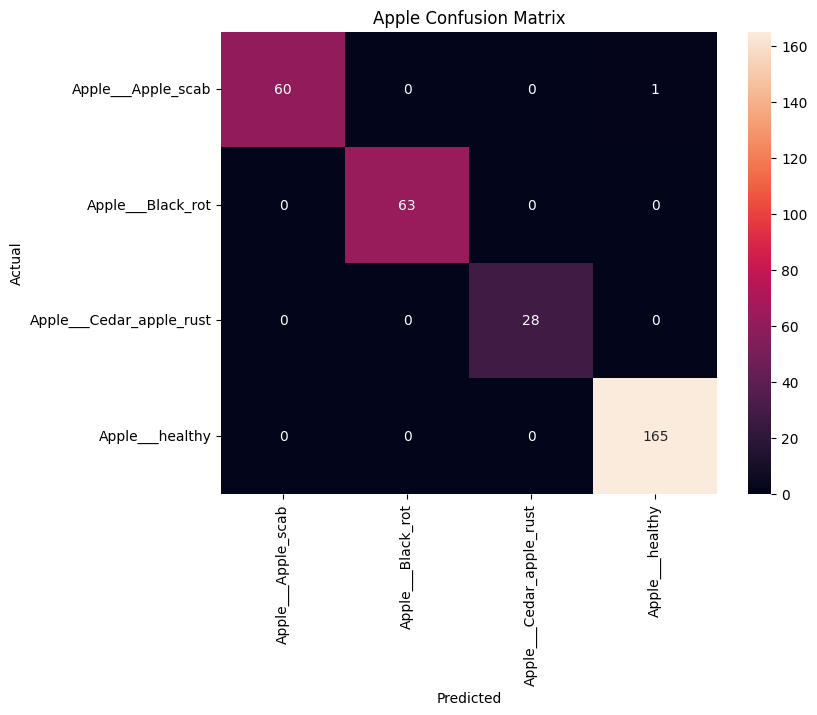


====== CONFUSION MATRIX: POTATO ======



Found 216 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


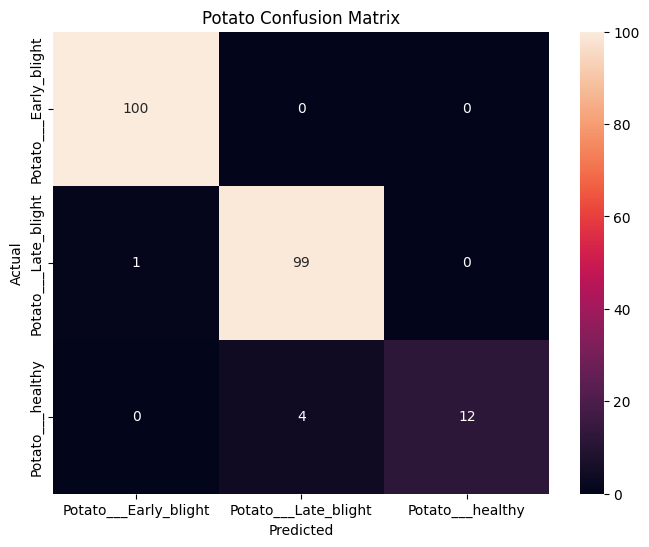


====== CONFUSION MATRIX: TOMATO ======



Found 394 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 909ms/step


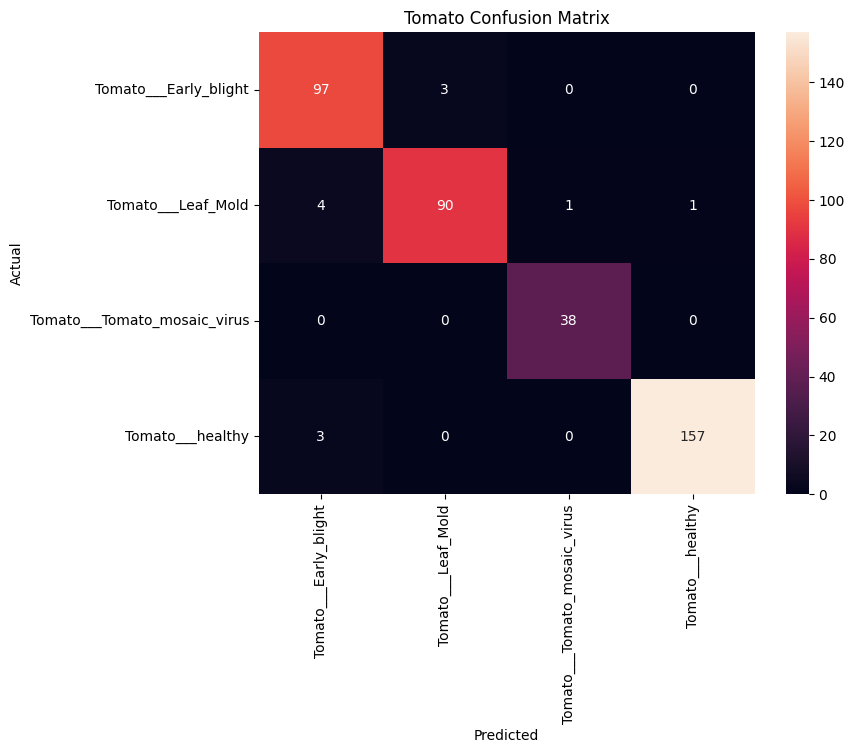


====== CONFUSION MATRIX: STRAWBERRY ======



Found 157 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


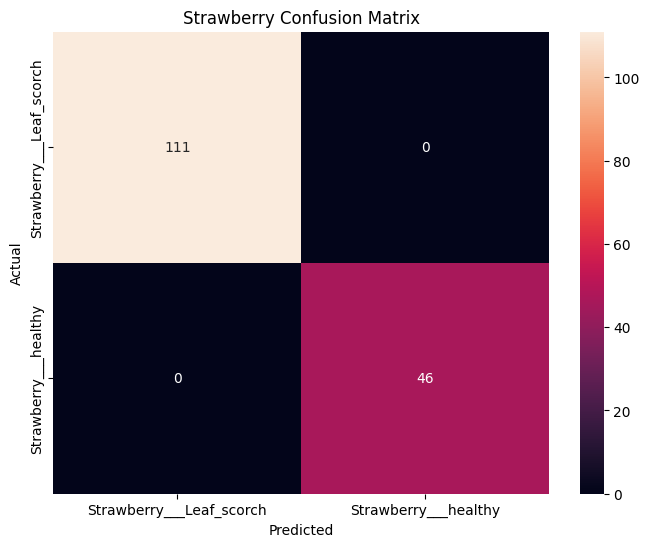

In [ ]:
# =========================
# CONFUSION MATRIX FOR EACH CROP
# =========================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import tensorflow as tf
import numpy as np
import os

ROOT_PROCESSED = "/content"   # where processed_crop folders are created
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def plot_confusion_matrix(crop):
    print(f"\n====== CONFUSION MATRIX: {crop.upper()} ======\n")

    WORK_DIR = f"{ROOT_PROCESSED}/processed_{crop.lower()}"
    MODEL_PATH = f"/content/drive/MyDrive/{crop.lower()}_disease_model.h5"

    # Load model
    model = tf.keras.models.load_model(MODEL_PATH)

    # Test generator
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

    test_gen = datagen.flow_from_directory(
        WORK_DIR + "/test",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    # Predictions
    y_true = test_gen.classes
    y_pred = np.argmax(model.predict(test_gen), axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    class_names = list(test_gen.class_indices.keys())

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{crop} Confusion Matrix")
    plt.show()


# =========================
# GENERATE FOR ALL CROPS
# =========================
for crop in ["Apple", "Potato", "Tomato", "Strawberry"]:
    plot_confusion_matrix(crop)

Mounted at /content/drive

========== TRAINING APPLE ==========

Found 2519 images belonging to 4 classes.
Found 314 images belonging to 4 classes.
Found 317 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


79/79 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.5081 - loss: 1.2451 - val_accuracy: 0.9076 - val_loss: 0.3475
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8814 - loss: 0.3493 - val_accuracy: 0.9490 - val_loss: 0.2074
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9375 - loss: 0.2081 - val_accuracy: 0.9713 - val_loss: 0.1489
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9481 - loss: 0.1742 - val_accuracy: 0.9745 - val_loss: 0.1178
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9648 - loss: 0.1249 - val_accuracy: 0.9777 - val_loss: 0.1039
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9680 - loss: 0.1063 - val_accuracy: 0.9809 - val_loss: 0.0832
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9691 - loss: 0.0967 - val_accuracy: 0.9841 - val_loss: 0.0750
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9807 - loss: 0.0730 - val_accuracy: 0.9873 - val_loss: 0.

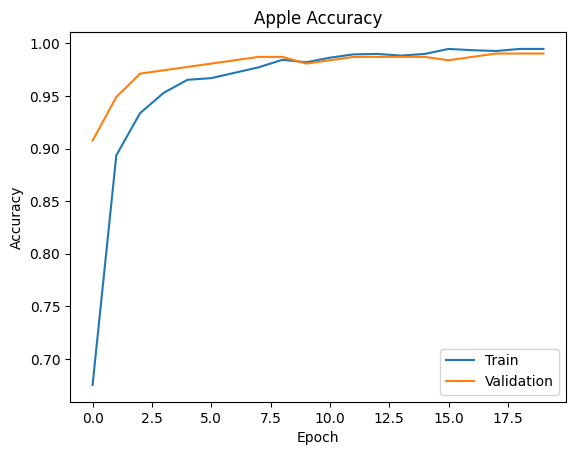

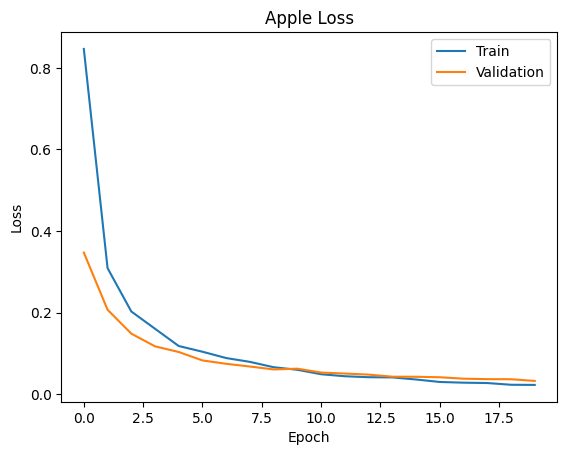

10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
                          precision    recall  f1-score   support

      Apple___Apple_scab       1.00      0.98      0.99        61
       Apple___Black_rot       1.00      1.00      1.00        63
Apple___Cedar_apple_rust       1.00      1.00      1.00        28
         Apple___healthy       0.99      1.00      1.00       165

                accuracy                           1.00       317
               macro avg       1.00      1.00      1.00       317
            weighted avg       1.00      1.00      1.00       317

Saved model for Apple

========== TRAINING POTATO ==========

Found 1721 images belonging to 3 classes.
Found 215 images belonging to 3 classes.
Found 216 images belonging to 3 classes.
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.5863 - loss: 0.8654 - val_accuracy: 0.8977 - val_loss: 0.3101
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8784 - loss: 0.3445 - val_accuracy: 0.9349 - val_loss: 0.2051
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9241 - loss: 0.2216 - val_accuracy: 0.9581 - val_loss: 0.1531
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9474 - loss: 0.1570 - val_accuracy: 0.9721 - val_loss: 0.1347
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9584 - loss: 0.1322 - val_accuracy: 0.9721 - val_loss: 0.1168
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9582 - loss: 0.1232 - val_accuracy: 0.9767 - val_loss: 0.1087
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9681 - loss: 0.1054 - val_accuracy: 0.9721 - val_loss: 0.0962
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9734 - loss: 0.0909 - val_accuracy: 0.9721 - val_loss: 0.0891
Epo

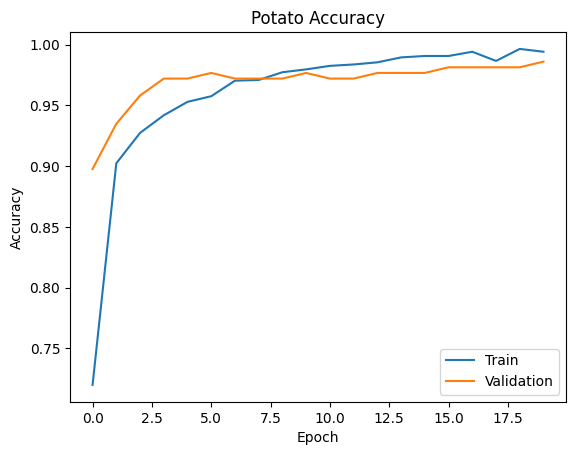

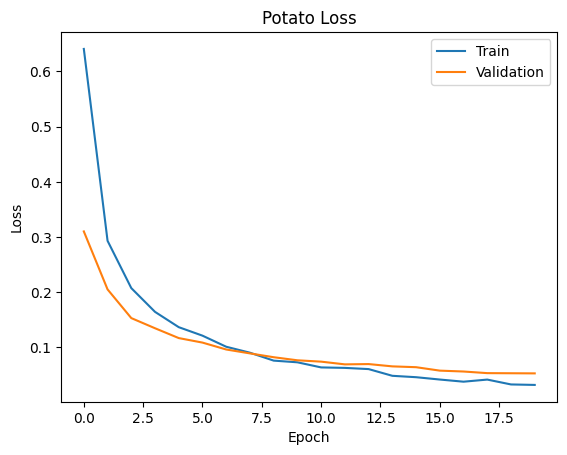

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
                       precision    recall  f1-score   support

Potato___Early_blight       0.99      1.00      1.00       100
 Potato___Late_blight       0.96      0.99      0.98       100
     Potato___healthy       1.00      0.75      0.86        16

             accuracy                           0.98       216
            macro avg       0.98      0.91      0.94       216
         weighted avg       0.98      0.98      0.98       216

Saved model for Potato

========== TRAINING TOMATO ==========

Found 3135 images belonging to 4 classes.
Found 391 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.5710 - loss: 1.0456 - val_accuracy: 0.8542 - val_loss: 0.4124
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.8603 - loss: 0.4228 - val_accuracy: 0.9207 - val_loss: 0.2791
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9066 - loss: 0.2924 - val_accuracy: 0.9182 - val_loss: 0.2351
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9333 - loss: 0.2239 - val_accuracy: 0.9488 - val_loss: 0.1887
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9422 - loss: 0.1895 - val_accuracy: 0.9463 - val_loss: 0.1738
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9567 - loss: 0.1585 - val_accuracy: 0.9565 - val_loss: 0.1522
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.9491 - loss: 0.1528 - val_accuracy: 0.9488 - val_loss: 0.1515
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9588 - loss: 0.1287 - val_accuracy: 0.9463 - v

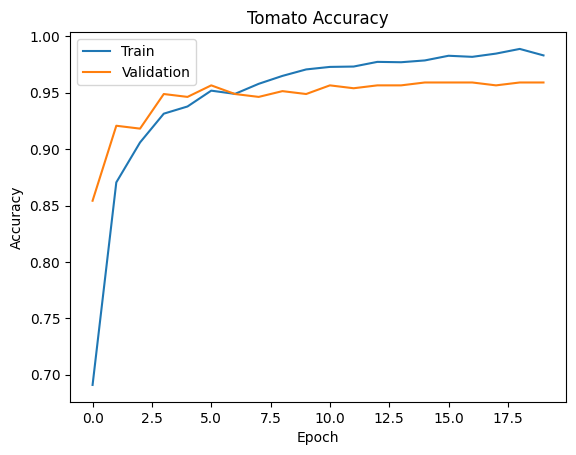

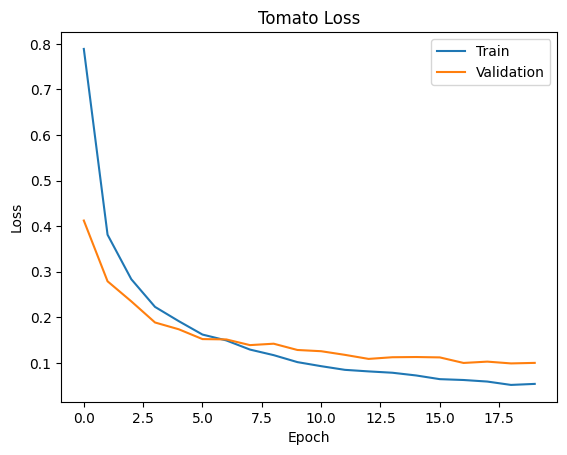

13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step
                              precision    recall  f1-score   support

       Tomato___Early_blight       0.93      0.97      0.95       100
          Tomato___Leaf_Mold       0.97      0.94      0.95        96
Tomato___Tomato_mosaic_virus       0.97      1.00      0.99        38
            Tomato___healthy       0.99      0.98      0.99       160

                    accuracy                           0.97       394
                   macro avg       0.97      0.97      0.97       394
                weighted avg       0.97      0.97      0.97       394

Saved model for Tomato

========== TRAINING STRAWBERRY ==========

Found 1251 images belonging to 2 classes.
Found 157 images belonging to 2 classes.
Found 157 images belonging to 2 classes.
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


40/40 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.8399 - loss: 0.3679 - val_accuracy: 0.9936 - val_loss: 0.0640
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9876 - loss: 0.0602 - val_accuracy: 0.9936 - val_loss: 0.0388
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9905 - loss: 0.0332 - val_accuracy: 0.9936 - val_loss: 0.0273
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9987 - loss: 0.0167 - val_accuracy: 0.9936 - val_loss: 0.0230
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9992 - loss: 0.0118 - val_accuracy: 0.9936 - val_loss: 0.0189
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.9936 - val_loss: 0.0184
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9991 - loss: 0.0083 - val_accuracy: 0.9936 - val_loss: 0.0146
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 0.9936 - val_loss: 0.0142
Epo

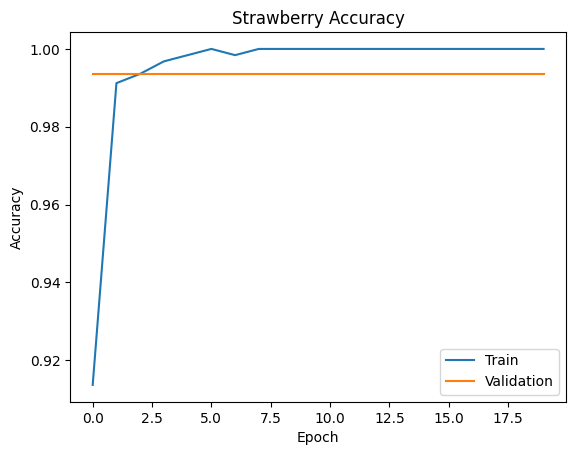

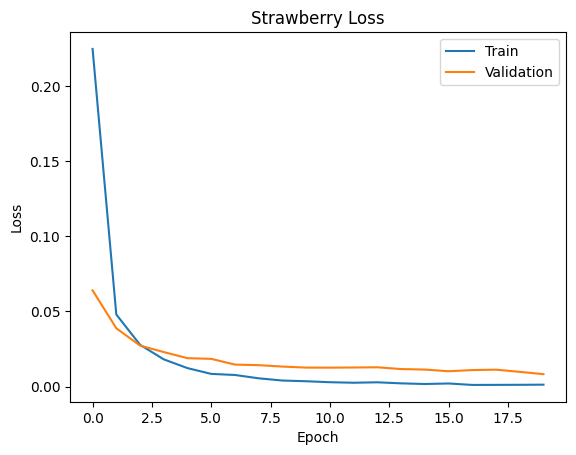

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
                          precision    recall  f1-score   support

Strawberry___Leaf_scorch       1.00      1.00      1.00       111
    Strawberry___healthy       1.00      1.00      1.00        46

                accuracy                           1.00       157
               macro avg       1.00      1.00      1.00       157
            weighted avg       1.00      1.00      1.00       157

Saved model for Strawberry


In [ ]:
# =========================
# SINGLE CELL: TRAIN EACH CROP + ACCURACY & LOSS CURVES + SAVE
# =========================

from google.colab import drive
drive.mount('/content/drive')

import os, random, shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

# CONFIG
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def get_crop_class_dirs(root, crop):
    dirs = []
    for r, d, f in os.walk(root):
        if os.path.basename(r).lower().startswith(crop.lower()):
            imgs = [x for x in f if x.lower().endswith(('.jpg','.jpeg','.png'))]
            if imgs:
                dirs.append(r)
    return dirs

def clean_images(class_dirs):
    for d in class_dirs:
        for f in os.listdir(d):
            p = os.path.join(d, f)
            if not os.path.isfile(p): continue
            try:
                Image.open(p).verify()
            except:
                os.remove(p)

def train_crop(crop):
    print(f"\n========== TRAINING {crop.upper()} ==========\n")
    WORK_DIR = f"/content/processed_{crop.lower()}"

    class_dirs = get_crop_class_dirs(ROOT_DIR, crop)
    clean_images(class_dirs)

    if os.path.exists(WORK_DIR):
        shutil.rmtree(WORK_DIR)

    for s in ["train","val","test"]:
        os.makedirs(os.path.join(WORK_DIR, s))

    for cls in class_dirs:
        cname = os.path.basename(cls)
        imgs = [i for i in os.listdir(cls) if i.lower().endswith(('.jpg','.png','.jpeg'))]
        random.shuffle(imgs)

        n = len(imgs)
        t1, t2 = int(0.8*n), int(0.9*n)

        splits = {
            "train": imgs[:t1],
            "val": imgs[t1:t2],
            "test": imgs[t2:]
        }

        for sp, files in splits.items():
            out = os.path.join(WORK_DIR, sp, cname)
            os.makedirs(out, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(cls, f), os.path.join(out, f))

    datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

    train_gen = datagen.flow_from_directory(
        WORK_DIR + "/train",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True
    )

    val_gen = datagen.flow_from_directory(
        WORK_DIR + "/val",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    test_gen = datagen.flow_from_directory(
        WORK_DIR + "/test",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    base = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(train_gen.num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(train_gen, epochs=EPOCHS, validation_data=val_gen)

    # Accuracy Curve
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f"{crop} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train","Validation"])
    plt.savefig(f"/content/drive/MyDrive/{crop.lower()}_accuracy_curve.png", dpi=300)
    plt.show()

    # Loss Curve
    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f"{crop} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train","Validation"])
    plt.savefig(f"/content/drive/MyDrive/{crop.lower()}_loss_curve.png", dpi=300)
    plt.show()

    y_true = test_gen.classes
    y_pred = np.argmax(model.predict(test_gen), axis=1)

    print(classification_report(
        y_true,
        y_pred,
        target_names=list(train_gen.class_indices.keys())
    ))

    model.save(f"/content/drive/MyDrive/{crop.lower()}_disease_model.keras")
    print("Saved model for", crop)

# Train all crops
for crop in ["Apple", "Potato", "Tomato", "Strawberry"]:
    train_crop(crop)